<a href="https://colab.research.google.com/github/BamlakHun/CNN_LTU/blob/main/Data_Augmentation_Fashion_MINST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import tensorflow
tensorflow.__version__

'2.19.0'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from tensorflow.keras.datasets import fashion_mnist
(x_train, y_train) , (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [5]:
x_train.shape

(60000, 28, 28)

In [6]:
x_test.shape

(10000, 28, 28)

In [7]:
y_train.shape

(60000,)

In [8]:
from collections import Counter
Counter(y_train)

Counter({np.uint8(9): 6000,
         np.uint8(0): 6000,
         np.uint8(3): 6000,
         np.uint8(2): 6000,
         np.uint8(7): 6000,
         np.uint8(5): 6000,
         np.uint8(1): 6000,
         np.uint8(6): 6000,
         np.uint8(4): 6000,
         np.uint8(8): 6000})

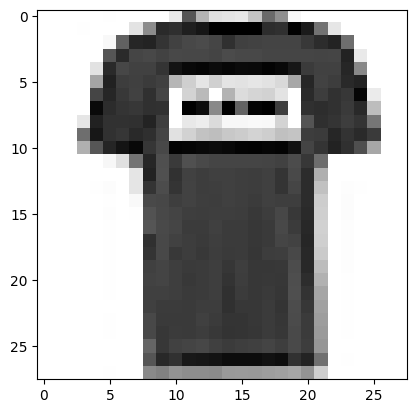

In [9]:
plt.imshow(x_train[1], cmap='Greys')
plt.show()

In [10]:
y_train[1]

np.uint8(0)

In [11]:
y_train.shape

(60000,)

In [12]:
from tensorflow.keras.utils import to_categorical
y_train_ohe = to_categorical(y_train, num_classes=10)
y_train_ohe.shape

(60000, 10)

In [13]:
import tensorflow as tf
y_test_ohe = tf.one_hot(y_test, depth=10)
y_test_ohe.shape

TensorShape([10000, 10])

In [14]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [15]:
print(f'Train set shape is: {x_train.shape}')
print(f'Test set shape is: {x_test.shape}')

Train set shape is: (60000, 28, 28)
Test set shape is: (10000, 28, 28)


In [16]:
x_train_ann = x_train.reshape(60000, 28*28)
x_train_ann = x_train_ann / 255.0

x_test_ann = x_test.reshape(10000, 28*28)
x_test_ann = x_test_ann / 255.0

In [17]:
x_train_ann.shape

(60000, 784)

In [18]:
ann_model = keras.Sequential(name="ann_mnist")
ann_model.add(layers.Input(shape=(784,))) # this is the shape of each sample!
ann_model.add(layers.Dense(units = 512, activation = 'relu', name="first_layer"))

#output layer
ann_model.add(layers.Dense(units = 10, activation = 'softmax', name="output_layer"))

In [19]:
ann_model.summary()

Model: "ann_mnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ first_layer (Dense)             │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
784*512+512

401920

In [21]:
512*10+10

5130

In [22]:
ann_model.compile(optimizer='rmsprop',
                  loss='categorical_crossentropy', metrics=['accuracy'])

In [23]:
from tensorflow.keras.callbacks import  ModelCheckpoint
modelcheckpoint  = ModelCheckpoint(filepath="ANN_benchmark.keras",save_best_only=True, monitor="val_loss")
callback_list    = [modelcheckpoint]

In [24]:
ann_model.fit(x_train_ann, y_train_ohe, validation_data=(x_test_ann, y_test_ohe), epochs=20, batch_size=128, callbacks=callback_list)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.7394 - loss: 0.7590 - val_accuracy: 0.8223 - val_loss: 0.5007
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.8529 - loss: 0.3999 - val_accuracy: 0.8510 - val_loss: 0.4050
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8726 - loss: 0.3447 - val_accuracy: 0.8594 - val_loss: 0.3913
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8841 - loss: 0.3143 - val_accuracy: 0.8754 - val_loss: 0.3410
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8913 - loss: 0.2934 - val_accuracy: 0.8697 - val_loss: 0.3555
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8949 - loss: 0.2818 - val_accuracy: 0.8707 - val_loss: 0.3691
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8990 - loss: 0.2681 - val_accuracy: 0.8827 - val_loss: 0.3281
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9049 - loss: 0.2577 - val_ac

In [25]:
test_model = keras.models.load_model("ANN_benchmark.keras")
test_model.evaluate(x_test_ann, y_test_ohe)

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.8796 - loss: 0.3349


[0.3280641734600067, 0.8827000260353088]

In [26]:
x_train.shape

(60000, 28, 28)

In [27]:
x_train = x_train.reshape((60000, 28,28,1))
x_train = x_train / 255.0

x_test = x_test.reshape((10000, 28,28,1))
x_test  = x_test / 255.0

In [28]:
x_train.shape

(60000, 28, 28, 1)

In [29]:
x_test.shape

(10000, 28, 28, 1)

In [30]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [31]:
def CNN_builder():
    inputs= keras.Input(shape=(28,28,1), name='Input layer')
    x = layers.Conv2D(filters= 32, kernel_size = 3, strides = (1,1) , padding='valid',  activation='relu' ,name="conv_layer_1")(inputs)
    x = layers.MaxPool2D(pool_size=2, name="pooling_1")(x)
    x = layers.Conv2D(filters= 64, kernel_size = 3, activation='relu', name="conv_layer_2")(x)
    x = layers.MaxPool2D(pool_size=2, name="pooling_2")(x)
    x = layers.Conv2D(filters= 128, kernel_size = 3, activation='relu', name="conv_layer_3")(x)
    x = layers.Flatten(name="flattening_layer")(x)

    outputs = layers.Dense(units= 10, activation='softmax', name='output_layer')(x)

    model = keras.Model(inputs= inputs , outputs=outputs, name='my_first_CNN_model')

    model.compile(optimizer='rmsprop',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

In [32]:
model = CNN_builder()
model.summary()

Model: "my_first_CNN_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_1 (Conv2D)           │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_1 (MaxPooling2D)        │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_2 (MaxPooling2D)        │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_3 (Conv2D)           │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flattening_layer (Flatten)      │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        11,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,202 (407.04 KB)

 Trainable params: 104,202 (407.04 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
1*(3*3)*32 + 32

320

In [34]:
32*(3*3)*64+64

18496

In [35]:
64*(3*3)*128+128

73856

In [36]:
3*3*128

1152

In [37]:
1152*10+10

11530

In [38]:
np.floor(((28+0-3)/1)+1)

np.float64(26.0)

Model fit

In [39]:
from tensorflow.keras.callbacks import  ModelCheckpoint
modelcheckpoint  = ModelCheckpoint(filepath="CNN_basic.keras",save_best_only=True, monitor="val_loss")
callback_list    = [modelcheckpoint]

In [40]:
history = model.fit(x=x_train, y=y_train_ohe, validation_data=(x_test, y_test_ohe),
          epochs=20, batch_size=128, callbacks=callback_list)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 58s 122ms/step - accuracy: 0.6963 - loss: 0.8366 - val_accuracy: 0.8370 - val_loss: 0.4334
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 120ms/step - accuracy: 0.8633 - loss: 0.3792 - val_accuracy: 0.8720 - val_loss: 0.3561
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 121ms/step - accuracy: 0.8808 - loss: 0.3217 - val_accuracy: 0.8872 - val_loss: 0.3173
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 55s 118ms/step - accuracy: 0.9005 - loss: 0.2763 - val_accuracy: 0.8876 - val_loss: 0.3070
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 55s 117ms/step - accuracy: 0.9066 - loss: 0.2531 - val_accuracy: 0.8964 - val_loss: 0.2971
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 55s 118ms/step - accuracy: 0.9128 - loss: 0.2336 - val_accuracy: 0.9016 - val_loss: 0.2806
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 119ms/step - accuracy: 0.9231 - loss: 0.2116 - val_accuracy: 0.8916 - val_loss: 0.2990
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 117ms/step - accuracy: 0.9265 - loss: 0

In [41]:
test_model = keras.models.load_model("CNN_basic.keras")
test_model.evaluate(x_test, y_test_ohe)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9078 - loss: 0.2676


[0.2561309337615967, 0.909500002861023]

Model evaluation

In [42]:
model.metrics_names

['loss', 'compile_metrics']

In [43]:
metrics = pd.DataFrame(history.history)

In [44]:
metrics.head()

,accuracy,loss,val_accuracy,val_loss
0,0.783150,0.589739,0.8370,0.433373
1,0.869400,0.362463,0.8720,0.356121
2,0.886633,0.308652,0.8872,0.317324
3,0.899633,0.275494,0.8876,0.307001
4,0.907717,0.252976,0.8964,0.297107


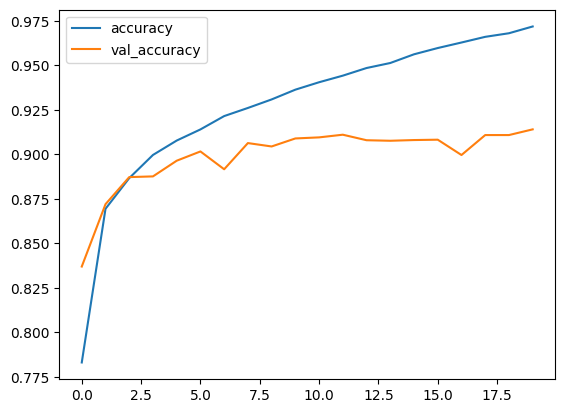

In [45]:
metrics[['accuracy','val_accuracy']].plot()
plt.show()

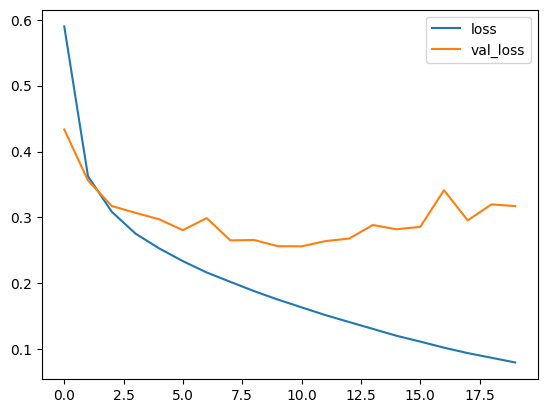

In [46]:
metrics[['loss','val_loss']].plot()
plt.show()

Data Augmentation

In [47]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        #layers.RandomRotation(0.1),
        #layers.RandomZoom(0.2),
    ]
)

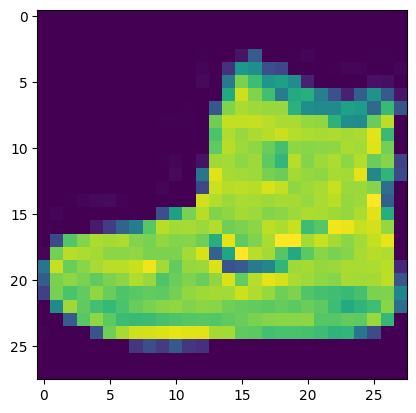

In [48]:
plt.imshow(x_train[0].reshape(28,28))
plt.show()

In [49]:
image = x_train[0]
image.shape

(28, 28, 1)

In [50]:
data_augmentation(image).numpy().shape

(28, 28, 1)

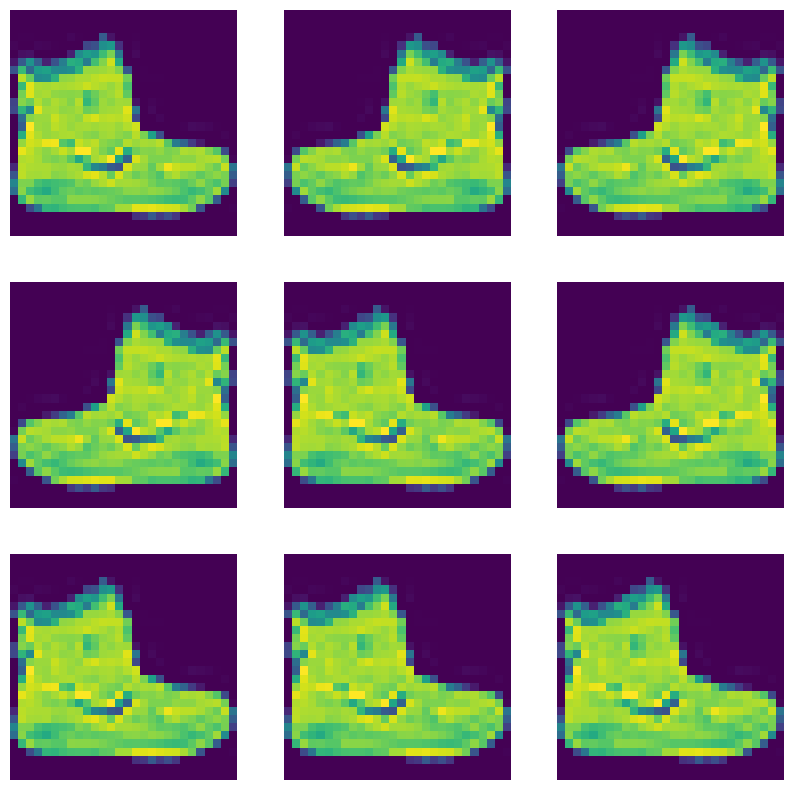

In [51]:
plt.figure(figsize=(10, 10))
for i in range(9):
    augmented_images = data_augmentation(image)
    ax = plt.subplot(3, 3, i + 1)

    plt.imshow(augmented_images.numpy().reshape(28,28))
    plt.axis("off")

In [52]:
x= data_augmentation(x_train)
x.shape

TensorShape([60000, 28, 28])

In [53]:
x = tf.expand_dims(x, axis=-1)
x.shape

TensorShape([60000, 28, 28, 1])

In [54]:
x = tf.squeeze(x, axis=-1)
x.shape

TensorShape([60000, 28, 28])

In [55]:
def CNN_builder_augmented():
  inputs= keras.Input(shape=(28,28,1), name='Input layer')
  x = data_augmentation(inputs)
  x = layers.Rescaling(1./255)(x)  # Add rescaling to normalize the data
  # Explicitly set the shape to ensure the augmented data is in the correct format
  x = layers.Reshape((28, 28, 1))(x)
  x = layers.Conv2D(filters= 32, kernel_size = 3, strides = (1,1) , padding='valid',  activation='relu' ,name="conv_layer_1")(x)
  x = layers.MaxPool2D(pool_size=2, name="pooling_1")(x)
  x = layers.Conv2D(filters= 64, kernel_size = 3, activation='relu', name="conv_layer_2")(x)
  x = layers.MaxPool2D(pool_size=2, name="pooling_2")(x)
  x = layers.Conv2D(filters= 128, kernel_size = 3, activation='relu', name="conv_layer_3")(x)
  x = layers.Flatten(name="flattening_layer")(x)
  x = layers.Dropout(0.5)(x)

  outputs = layers.Dense(units= 10, activation='softmax', name='output_layer')(x)

  model = keras.Model(inputs= inputs , outputs=outputs, name='CNN_augmented_model')

  model.compile(optimizer='rmsprop',
                loss='categorical_crossentropy',
                metrics=['accuracy'])
  return model

In [56]:
model_augmented = CNN_builder_augmented()
model_augmented.summary()

Model: "CNN_augmented_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_1 (Conv2D)           │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_1 (MaxPooling2D)        │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_2 (MaxPooling2D)        │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_3 (Conv2D)           │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flattening_layer (Flatten)      │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        11,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,202 (407.04 KB)

 Trainable params: 104,202 (407.04 KB)

 Non-trainable params: 0 (0.00 B)

Model fit

In [57]:
from tensorflow.keras.callbacks import  ModelCheckpoint
modelcheckpoint  = ModelCheckpoint(filepath="CNN_augmented.keras",save_best_only=True, monitor="val_loss")
callback_list    = [modelcheckpoint]

In [58]:
history = model_augmented.fit(x=x_train, y=y_train_ohe, validation_data=(x_test, y_test_ohe),
          epochs=20, batch_size=128, callbacks=callback_list)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 131ms/step - accuracy: 0.0995 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 130ms/step - accuracy: 0.1001 - loss: 2.3026 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 62s 131ms/step - accuracy: 0.0998 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 128ms/step - accuracy: 0.0979 - loss: 2.3026 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 57s 122ms/step - accuracy: 0.0985 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 55s 117ms/step - accuracy: 0.1016 - loss: 2.3026 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 55s 118ms/step - accuracy: 0.0993 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 117ms/step - accuracy: 0.1025 - loss: 2

In [59]:
model_augmented.evaluate(x_test, y_test_ohe)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.0984 - loss: 2.3027


[2.302593231201172, 0.10000000149011612]

Model evaluation

In [60]:
metrics = pd.DataFrame(history.history)

In [61]:
metrics.head()

,accuracy,loss,val_accuracy,val_loss
0,0.098167,2.302790,0.1,2.302598
1,0.099050,2.302681,0.1,2.302609
2,0.099083,2.302695,0.1,2.302594
3,0.097600,2.302672,0.1,2.302605
4,0.098667,2.302670,0.1,2.302612


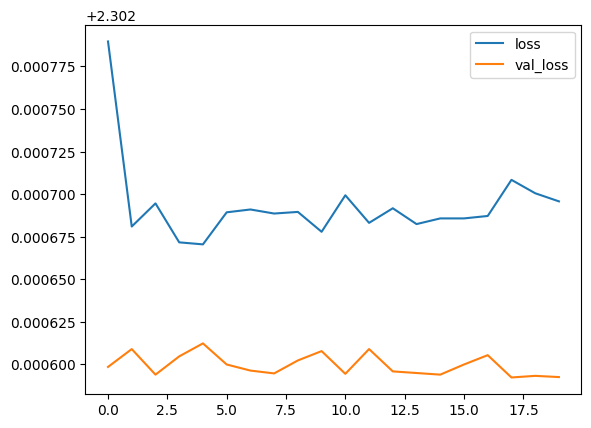

In [63]:
metrics[['loss','val_loss']].plot()
plt.show()

Model predictions

In [64]:
model = keras.models.load_model("CNN_basic.keras")

In [65]:
model.summary()

Model: "my_first_CNN_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_1 (Conv2D)           │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_1 (MaxPooling2D)        │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_2 (MaxPooling2D)        │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_3 (Conv2D)           │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flattening_layer (Flatten)      │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        11,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 208,406 (814.09 KB)

 Trainable params: 104,202 (407.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 104,204 (407.05 KB)

In [66]:
predictions_prob = model.predict(x_test)
predictions_prob[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


array([8.3256522e-09, 1.5620857e-10, 4.8942299e-09, 2.0903665e-09,
       8.2437897e-11, 2.5653082e-04, 3.8275192e-09, 7.8974153e-05,
       2.7583094e-06, 9.9966168e-01], dtype=float32)

In [67]:
predictions_prob[0].argmax()

np.int64(9)

In [68]:
y_test[0]

np.uint8(9)

In [69]:
predictions = np.argmax(predictions_prob, axis=1)
predictions[0:5]

array([9, 2, 1, 1, 6])

In [70]:
from sklearn.metrics import classification_report,confusion_matrix

In [71]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1000
           1       1.00      0.98      0.99      1000
           2       0.88      0.86      0.87      1000
           3       0.93      0.91      0.92      1000
           4       0.89      0.84      0.86      1000
           5       0.98      0.99      0.98      1000
           6       0.72      0.74      0.73      1000
           7       0.97      0.94      0.96      1000
           8       0.98      0.98      0.98      1000
           9       0.95      0.98      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [72]:
confusion_matrix(y_test,predictions)

array([[882,   0,  16,   9,   4,   1,  81,   0,   7,   0],
       [  4, 978,   1,  12,   0,   0,   3,   0,   2,   0],
       [ 21,   0, 856,   5,  41,   0,  77,   0,   0,   0],
       [ 21,   1,  10, 912,  17,   0,  35,   0,   4,   0],
       [  3,   1,  37,  27, 841,   0,  90,   0,   1,   0],
       [  0,   0,   0,   0,   0, 986,   1,   8,   0,   5],
       [141,   0,  48,  16,  45,   0, 741,   0,   9,   0],
       [  0,   0,   0,   0,   0,  13,   0, 939,   0,  48],
       [  2,   0,   4,   3,   2,   1,   3,   4, 980,   1],
       [  1,   0,   0,   0,   0,   6,   0,  13,   0, 980]])

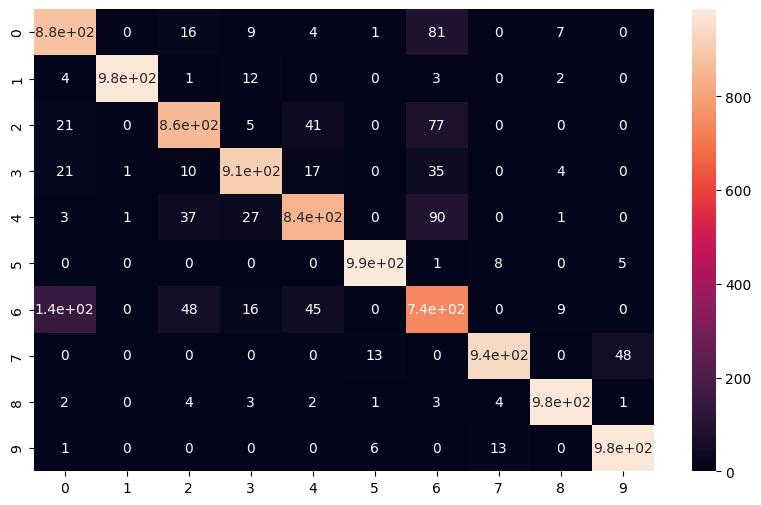

In [73]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(confusion_matrix(y_test,predictions),annot=True)
plt.show()

In [74]:
y_test!=predictions

array([False, False, False, ..., False, False, False])

In [75]:
misclassified_images = [i for i, x in enumerate(y_test!=predictions) if x==True]
misclassified_images[:9]

[17, 23, 25, 42, 43, 49, 57, 66, 68]

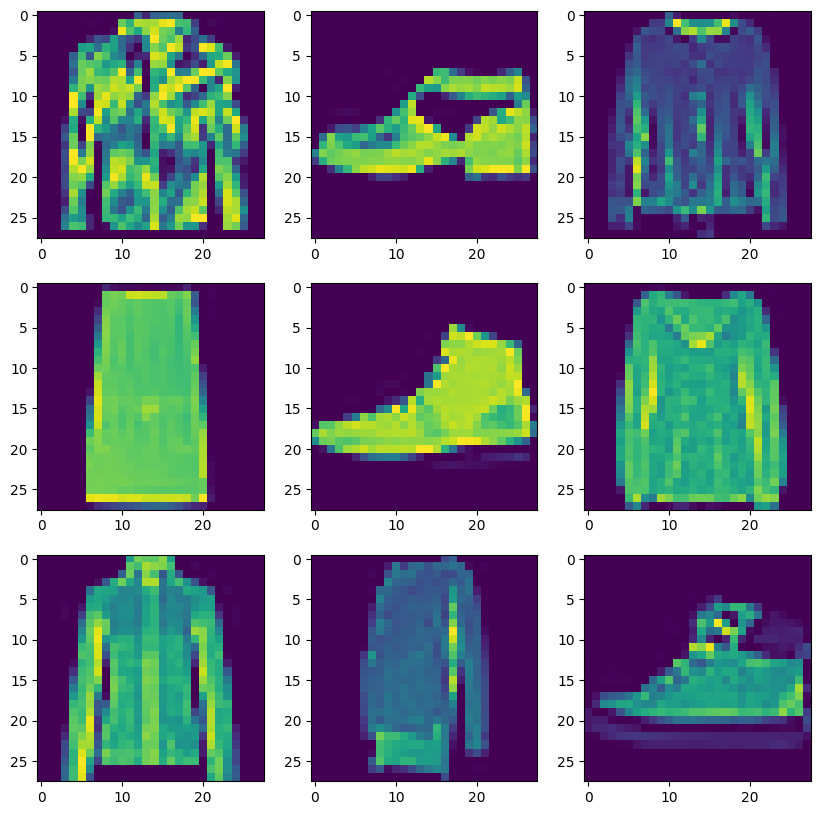

In [76]:
plt.figure(figsize=(10,10))

actuals = []
for i , number in enumerate(misclassified_images[:9]):
  ax = plt.subplot(3,3,i+1)
  plt.imshow(x_test[number].reshape(28,28))
  actuals.append(y_test[number])
plt.show()

In [77]:
list(predictions[misclassified_images[:9]])

[np.int64(6),
 np.int64(5),
 np.int64(6),
 np.int64(6),
 np.int64(9),
 np.int64(6),
 np.int64(6),
 np.int64(0),
 np.int64(7)]

In [78]:
actuals

[np.uint8(4),
 np.uint8(9),
 np.uint8(4),
 np.uint8(3),
 np.uint8(7),
 np.uint8(2),
 np.uint8(4),
 np.uint8(2),
 np.uint8(9)]